In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/map.npz"
fixed_point_map = FixedPointMap.load(map_path)

Quimb not available.


In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state



map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/map.npz"
fixed_point_map = FixedPointMap.load(map_path)

In [3]:
def calculate_action(bvp_result):
    
    def integrand_func(t):
        integrand = -bvp_result.sol(t,nu=1)[0]*bvp_result.sol(t)[2]
        integrand -= bvp_result.sol(t,nu=1)[1]*bvp_result.sol(t)[3]
        return integrand

    action, action_error = scipy.integrate.quad(integrand_func, 0, bvp_result.x[-1], limit=2000, epsabs=1e-2)
    return action, action_error

In [4]:
calculate_action(fixed_point_map.path_results[360,80])


(-1.6600330552299545, 0.0013958053042051333)

In [5]:
actions_array = np.zeros(fixed_point_map.kappa_linspace.shape)

from tqdm import tqdm

for idx in tqdm(range(5, 230)):
    bvp_result = fixed_point_map.path_results[360,idx]
    action, action_error = calculate_action(bvp_result)
    actions_array[idx] = action

100%|██████████| 225/225 [00:00<00:00, 319.92it/s]


(-14.0, 1.0)

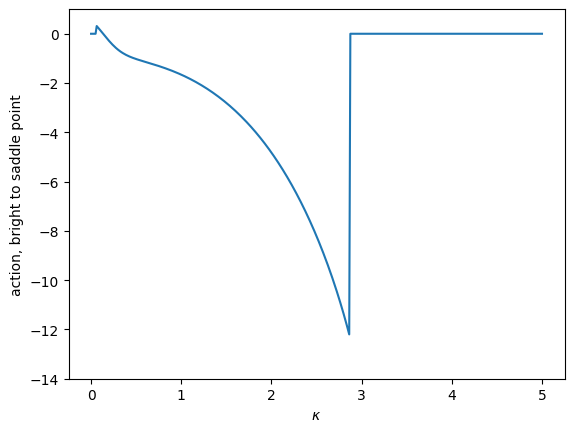

In [6]:
plt.plot(fixed_point_map.kappa_linspace, actions_array)
plt.xlabel(r'$\kappa$')
plt.ylabel(r'action, bright to saddle point')
plt.ylim([-14,1])

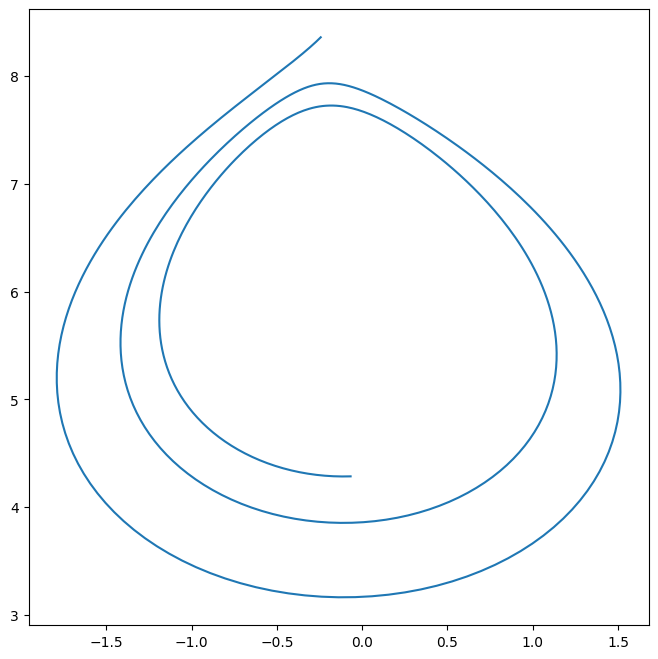

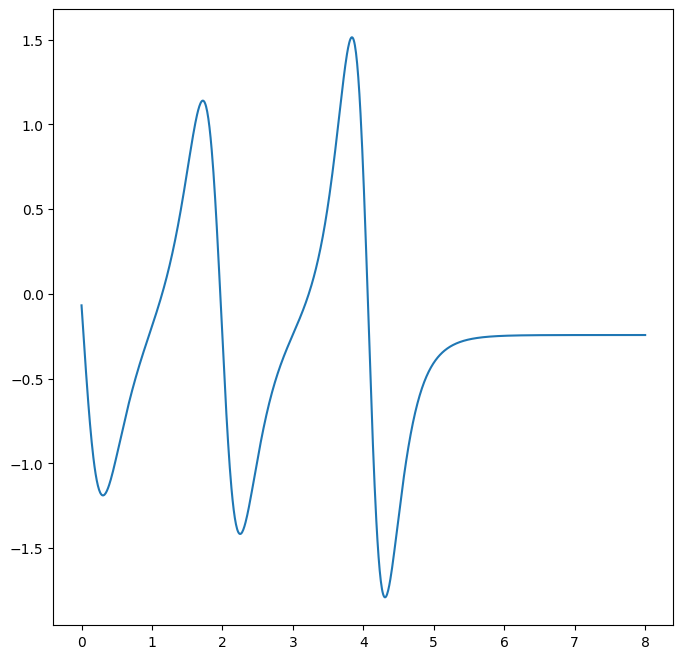

0.038499080341835024
0.125


In [7]:
kappa_idx = 10
res = fixed_point_map.path_results[360,kappa_idx]
fig, axes = plt.subplots(1,1,figsize=(8, 8))
t_plot = np.linspace(0, res.x[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)



fig, axes = plt.subplots(1,1,figsize=(8, 8))
t_plot = np.linspace(0, res.x[-1], 1001)
y0_plot = res.sol(t_plot)[0]
axes.plot(t_plot,y0_plot)


plt.show()

action, action_error = calculate_action(res)

print(action)
print(fixed_point_map.kappa_linspace[kappa_idx])

In [13]:
fixed_point_map.fixed_points[360,100]

array([[ -2.73912696,   8.44890762],
       [ -6.95507583, -12.32611472],
       [ -1.13913055,   5.61331821]])